## Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 44639 files belonging to 8 classes.


### Validation Image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 11959 files belonging to 8 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 8), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[137.        64.        45.      ]
   [128.        53.        33.5     ]
   [140.        62.5       42.5     ]
   ...
   [161.       163.       162.      ]
   [160.       162.       161.      ]
   [165.75     167.75     166.75    ]]

  [[134.25      60.25      40.75    ]
   [130.5       54.5       34.      ]
   [139.        61.75      40.      ]
   ...
   [160.5      162.       162.5     ]
   [161.       162.5      163.      ]
   [167.5      169.       169.5     ]]

  [[137.75      61.75      41.25    ]
   [132.        55.        35.      ]
   [138.75      62.25      39.5     ]
   ...
   [159.5      163.5      164.5     ]
   [159.25     163.25     164.25    ]
   [165.5      169.5      170.5     ]]

  ...

  [[149.25     155.25     154.25    ]
   [152.25     158.25     157.25    ]
   [157.5      163.5      162.5     ]
   ...
   [134.75     154.75     144.75    ]
   [131.75     149.75     137.75    ]
   [123.       140.       125.5     ]]

  [[149.75     155.75     154.75  

### To avoid Overshooting
1. Choose small learning rate default 0.001 here we have taken 0.0001 
2. There may be chance of underfitting so increase number of neuron 
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [6]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [7]:
model = Sequential()

## Building Convolution Layer

In [8]:
model.add(Input(shape=(128, 128, 3)))

In [9]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [14]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [15]:
model.add(Flatten())

In [16]:
model.add(Dense(units=1500,activation='relu'))

In [17]:
model.add(Dropout(0.4))

In [18]:
#Output Layer
model.add(Dense(units=8,activation='softmax'))

## Compiling Model

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │          12,008 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,797,732 (29.75 MB)

 Trainable params: 7,797,732 (29.75 MB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [21]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=15)

Epoch 1/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 915s 653ms/step - accuracy: 0.6837 - loss: 0.8767 - val_accuracy: 0.8174 - val_loss: 0.5248
Epoch 2/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 732s 525ms/step - accuracy: 0.8543 - loss: 0.4224 - val_accuracy: 0.8968 - val_loss: 0.2919
Epoch 3/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 717s 514ms/step - accuracy: 0.9063 - loss: 0.2719 - val_accuracy: 0.9134 - val_loss: 0.2586
Epoch 4/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 699s 501ms/step - accuracy: 0.9330 - loss: 0.1984 - val_accuracy: 0.9375 - val_loss: 0.1922
Epoch 5/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 701s 503ms/step - accuracy: 0.9508 - loss: 0.1439 - val_accuracy: 0.9496 - val_loss: 0.1571
Epoch 6/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 705s 505ms/step - accuracy: 0.9639 - loss: 0.1050 - val_accuracy: 0.9452 - val_loss: 0.1920
Epoch 7/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 745s 534ms/step - accuracy: 0.9711 - loss: 0.0862 - val_accuracy: 0.9554 - val_loss: 0.1533
Epoch 8/15
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 722s 518ms/step - ac

## Evaluating Model

In [22]:
# Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

1395/1395 ━━━━━━━━━━━━━━━━━━━━ 165s 118ms/step - accuracy: 0.9913 - loss: 0.0285


In [23]:
print(train_loss, train_acc)

0.028497718274593353 0.9912856221199036


In [24]:
# Model on Validation set
val_loss, val_acc = model.evaluate(validation_set)

374/374 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.9642 - loss: 0.1451


In [25]:
print(val_loss, val_acc)

0.14512552320957184 0.9642110466957092


## Saving Model

In [26]:
model.save("rice_trained_model.keras")

In [27]:
training_history.history

{'accuracy': [0.6836846470832825,
  0.8542978167533875,
  0.9063150882720947,
  0.9330406188964844,
  0.950760543346405,
  0.9639328718185425,
  0.9711239337921143,
  0.9769707918167114,
  0.9804655313491821,
  0.9839602112770081,
  0.986693263053894,
  0.9855507612228394,
  0.989963948726654,
  0.9894710779190063,
  0.9910168051719666],
 'loss': [0.8766911625862122,
  0.4223957657814026,
  0.27189743518829346,
  0.19837608933448792,
  0.14392592012882233,
  0.10504157841205597,
  0.08615723997354507,
  0.06806551665067673,
  0.0596056766808033,
  0.04801471531391144,
  0.04049541428685188,
  0.04294321686029434,
  0.03227708488702774,
  0.033744506537914276,
  0.029743121936917305],
 'val_accuracy': [0.8173760175704956,
  0.8968141078948975,
  0.913370668888092,
  0.9375365972518921,
  0.9495777487754822,
  0.9452295303344727,
  0.9554310441017151,
  0.9602809548377991,
  0.957103431224823,
  0.9613680243492126,
  0.9599465131759644,
  0.9547621011734009,
  0.9642110466957092,
  0.961

In [28]:
# Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [29]:
training_history.history['accuracy']

[0.6836846470832825,
 0.8542978167533875,
 0.9063150882720947,
 0.9330406188964844,
 0.950760543346405,
 0.9639328718185425,
 0.9711239337921143,
 0.9769707918167114,
 0.9804655313491821,
 0.9839602112770081,
 0.986693263053894,
 0.9855507612228394,
 0.989963948726654,
 0.9894710779190063,
 0.9910168051719666]

In [30]:
training_history.history['val_accuracy']

[0.8173760175704956,
 0.8968141078948975,
 0.913370668888092,
 0.9375365972518921,
 0.9495777487754822,
 0.9452295303344727,
 0.9554310441017151,
 0.9602809548377991,
 0.957103431224823,
 0.9613680243492126,
 0.9599465131759644,
 0.9547621011734009,
 0.9642110466957092,
 0.961953341960907,
 0.9642110466957092]

### Accuracy Visualization

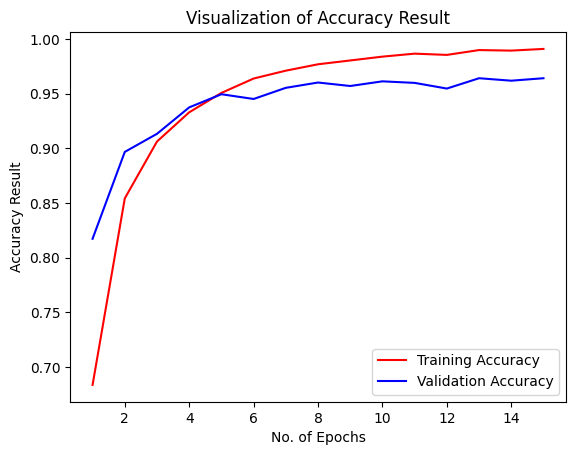

In [31]:
epochs = [i for i in range (1,16)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

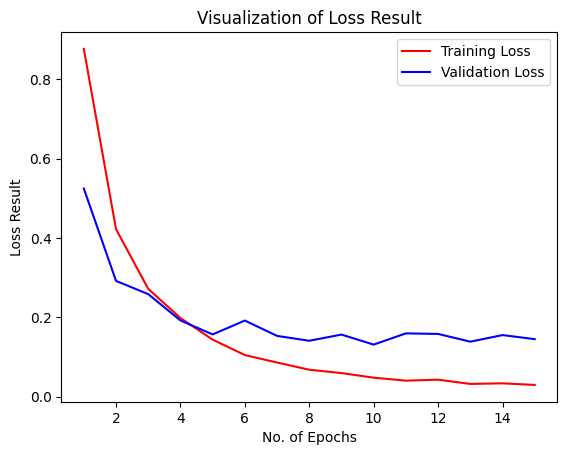

In [32]:
epochs = [i for i in range (1,16)]
plt.plot(epochs, training_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, training_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss Result")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [33]:
class_name = validation_set.class_names
class_name

['Healthy Rice Leaves',
 'Rice Bacterial Blight',
 'Rice Brown Spots',
 'Rice Leaf Blast',
 'Rice Leaf Scaled',
 'Rice Leaf Smut',
 'Rice Sheath Blight',
 'Rice Tungro']

In [34]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 5980 files belonging to 8 classes.


In [35]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 139ms/step


(array([[9.9998295e-01, 1.1892173e-09, 1.0756806e-05, ..., 3.0297537e-10,
         3.3698054e-08, 1.6874322e-09],
        [9.9990380e-01, 5.4671864e-11, 2.5806721e-05, ..., 6.2210057e-11,
         7.6915727e-09, 2.7070266e-11],
        [9.9999988e-01, 3.3612910e-09, 1.9064288e-10, ..., 2.4190575e-13,
         2.1605635e-14, 3.3306899e-13],
        ...,
        [9.9164772e-06, 6.9141890e-05, 5.7857305e-06, ..., 3.5078494e-07,
         4.2631225e-05, 9.9963939e-01],
        [9.6013704e-09, 1.4019426e-08, 1.1507369e-08, ..., 9.3697904e-11,
         3.5808649e-09, 9.9998176e-01],
        [5.0884064e-15, 6.1066554e-16, 1.5095211e-16, ..., 1.7742489e-20,
         3.5435776e-15, 1.0000000e+00]], shape=(5980, 8), dtype=float32),
 (5980, 8))

In [36]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(5980,), dtype=int64, numpy=array([0, 0, 0, ..., 7, 7, 7], shape=(5980,))>

In [37]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(5980, 8), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(5980, 8), dtype=float32)>

In [38]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(5980,), dtype=int64, numpy=array([0, 0, 0, ..., 7, 7, 7], shape=(5980,))>

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                       precision    recall  f1-score   support

  Healthy Rice Leaves       0.96      0.98      0.97       709
Rice Bacterial Blight       0.98      0.98      0.98       800
     Rice Brown Spots       0.97      0.96      0.97       706
      Rice Leaf Blast       0.90      0.94      0.92       675
     Rice Leaf Scaled       0.99      0.95      0.97       800
       Rice Leaf Smut       0.99      0.99      0.99       800
   Rice Sheath Blight       0.98      0.92      0.95       690
          Rice Tungro       0.96      0.99      0.97       800

             accuracy                           0.97      5980
            macro avg       0.97      0.97      0.97      5980
         weighted avg       0.97      0.97      0.97      5980



In [41]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

array([[695,   1,   3,  10,   0,   0,   0,   0],
       [  3, 788,   1,   1,   1,   0,   0,   6],
       [  8,   0, 680,  13,   0,   1,   3,   1],
       [ 18,   0,  10, 632,   2,   4,   8,   1],
       [  2,   5,   1,   2, 762,   0,   3,  25],
       [  0,   6,   0,   3,   0, 791,   0,   0],
       [  1,   2,   5,  42,   1,   1, 638,   0],
       [  0,   3,   2,   0,   3,   0,   0, 792]])

### Confusion Matrix Visualiation

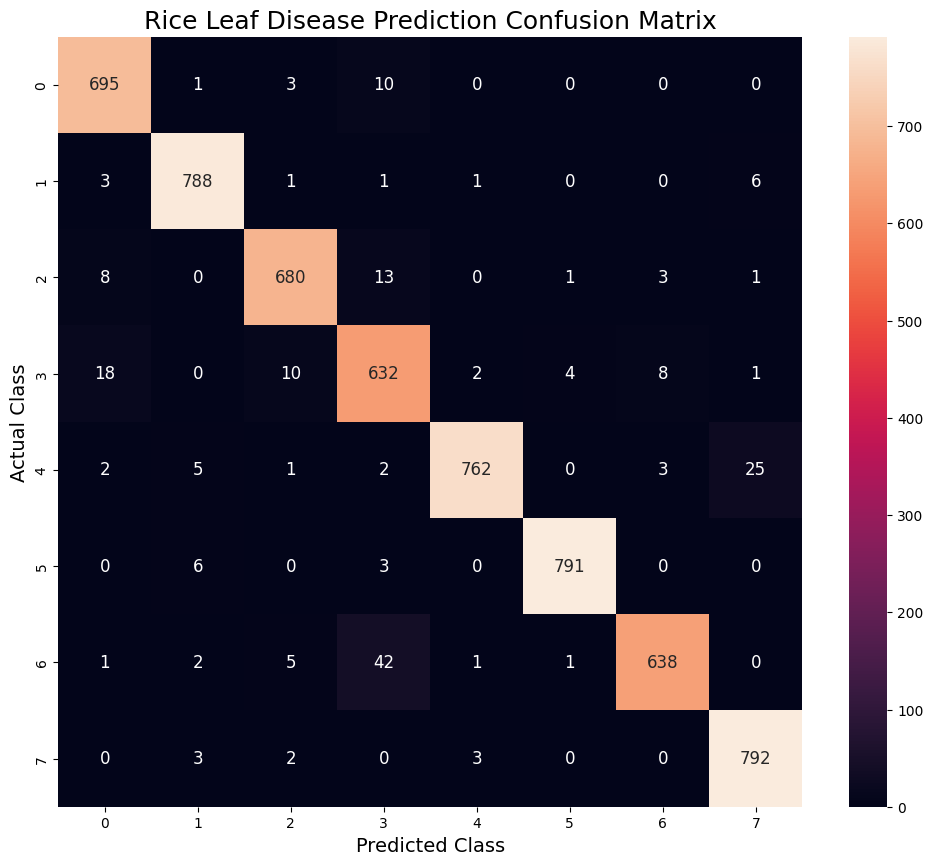

In [42]:
plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    annot_kws={"size": 12}
)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)
plt.title("Rice Leaf Disease Prediction Confusion Matrix", fontsize=18)
plt.show()